## Customer Segmentation 

---
### Importing Libraries

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

---
### Loading & Inspecting Dataset

In [45]:
df = pd.read_csv('OnlineRetail_Cleaned.csv')
df.head()

,InvoiceDate,CustomerID,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Country,InvoiceDate.1,Year,Quarter,MonthName,DayName,TotalPrice
0,2010-12-01,17850.0,536365,85123A,White Hanging Heart T-Light Holder,6,2.55,United Kingdom,2010-12-01,2010,4,December,Wednesday,15.30
1,2010-12-01,17850.0,536365,71053,White Metal Lantern,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34
2,2010-12-01,17850.0,536365,84406B,Cream Cupid Hearts Coat Hanger,8,2.75,United Kingdom,2010-12-01,2010,4,December,Wednesday,22.00
3,2010-12-01,17850.0,536365,84029G,Knitted Union Flag Hot Water Bottle,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34
4,2010-12-01,17850.0,536365,84029E,Red Woolly Hottie White Heart.,6,3.39,United Kingdom,2010-12-01,2010,4,December,Wednesday,20.34


### Calculate the RFM Data frame

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 333045 entries, 0 to 333044
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   InvoiceDate    333045 non-null  str    
 1   CustomerID     333045 non-null  int64  
 2   InvoiceNo      333045 non-null  int64  
 3   StockCode      333045 non-null  str    
 4   Description    333045 non-null  str    
 5   Quantity       333045 non-null  int64  
 6   UnitPrice      333045 non-null  float64
 7   Country        333045 non-null  str    
 8   InvoiceDate.1  333045 non-null  str    
 9   Year           333045 non-null  int64  
 10  Quarter        333045 non-null  int64  
 11  MonthName      333045 non-null  str    
 12  DayName        333045 non-null  str    
 13  TotalPrice     333045 non-null  float64
dtypes: float64(2), int64(5), str(7)
memory usage: 60.6 MB


In [50]:
df['CustomerID'] = df['CustomerID'].astype('int')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [51]:
## RFM Analysis
reference_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [52]:
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']
rfm['CustomerLifetime'] = df.groupby('CustomerID')['InvoiceDate'].agg(lambda x: (x.max() - x.min()).days)

In [53]:
rfm

,Recency,Frequency,Monetary,AvgOrderValue,CustomerLifetime
CustomerID,,,,,
12347,2,7,3314.73,473.532857,365
12348,248,3,90.20,30.066667,110
12349,18,1,999.15,999.150000,0
12350,310,1,294.40,294.400000,0
12352,36,7,1130.94,161.562857,260
...,...,...,...,...,...
18280,277,1,137.00,137.000000,0
18281,180,1,46.92,46.920000,0
18282,7,2,113.13,56.565000,119


In [54]:
rfm.columns

Index(['Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
       'CustomerLifetime'],
      dtype='str')

In [55]:
X = rfm[['Recency', 'Frequency', 'Monetary',
       'CustomerLifetime']]

X       


,Recency,Frequency,Monetary,CustomerLifetime
CustomerID,,,,
12347,2,7,3314.73,365
12348,248,3,90.20,110
12349,18,1,999.15,0
12350,310,1,294.40,0
12352,36,7,1130.94,260
...,...,...,...,...
18280,277,1,137.00,0
18281,180,1,46.92,0
18282,7,2,113.13,119


### Feature Scaling

In [56]:
from sklearn.preprocessing import MinMaxScaler

mm = MinMaxScaler()
X_scaled = mm.fit_transform(X)

In [57]:
X_scaled

array([[0.00536193, 0.03076923, 0.03898411, 0.97855228],
       [0.66487936, 0.01025641, 0.00103908, 0.29490617],
       [0.04825737, 0.        , 0.01173525, 0.        ],
       ...,
       [0.01876676, 0.00512821, 0.00130891, 0.31903485],
       [0.0080429 , 0.07692308, 0.02354382, 0.89544236],
       [0.11260054, 0.01025641, 0.01128349, 0.42627346]], shape=(4188, 4))

---
### Elbow Method (k = ?!)

In [58]:
from sklearn.cluster import KMeans

ssd = []

for i in range(2,11):
    km = KMeans(n_clusters= i , init='k-means++' , random_state= 42)
    km.fit(X_scaled)

    ssd.append(km.inertia_)

ssd    

[328.94406897701975,
 159.1413267219492,
 105.32223571832665,
 88.01199128295225,
 74.31270346943283,
 55.50378348961246,
 48.98975154911369,
 42.35827466172657,
 38.87873117714341]

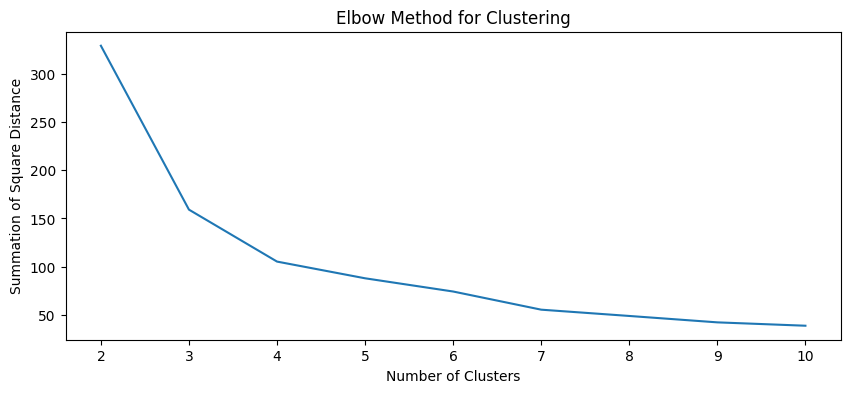

In [59]:
plt.figure(figsize=(10,4))
plt.plot(range(2,11) , ssd)
plt.xlabel('Number of Clusters')
plt.ylabel('Summation of Square Distance')
plt.title("Elbow Method for Clustering")
plt.show()

In [60]:
from sklearn.cluster import KMeans
km_model = KMeans(n_clusters= 4 , init='k-means++' , random_state= 42)

km_model.fit(X_scaled)



,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [61]:
km_model.labels_

array([0, 2, 1, ..., 3, 0, 3], shape=(4188,), dtype=int32)

In [62]:
X['cluster'] = km_model.labels_

In [63]:
X

,Recency,Frequency,Monetary,CustomerLifetime,cluster
CustomerID,,,,,
12347,2,7,3314.73,365,0
12348,248,3,90.20,110,2
12349,18,1,999.15,0,1
12350,310,1,294.40,0,2
12352,36,7,1130.94,260,0
...,...,...,...,...,...
18280,277,1,137.00,0,2
18281,180,1,46.92,0,2
18282,7,2,113.13,119,3


In [64]:
X.groupby('cluster').mean()

,Recency,Frequency,Monetary,CustomerLifetime
cluster,,,,
0,22.201317,9.219191,2400.741355,315.974600
1,52.673406,1.664075,455.763243,17.365474
2,260.363029,1.407572,287.240124,14.827394
3,63.925611,3.843783,956.203913,178.993624


In [65]:
def map_segment(cluster):
    if cluster == 0:
        return "VIP"
    elif cluster == 1:
        return "Potential"
    elif cluster == 2:
        return "Lost"
    else:
        return "Regular"

rfm['Segment'] = X['cluster'].apply(map_segment)

In [66]:
rfm

,Recency,Frequency,Monetary,AvgOrderValue,CustomerLifetime,Segment
CustomerID,,,,,,
12347,2,7,3314.73,473.532857,365,VIP
12348,248,3,90.20,30.066667,110,Lost
12349,18,1,999.15,999.150000,0,Potential
12350,310,1,294.40,294.400000,0,Lost
12352,36,7,1130.94,161.562857,260,VIP
...,...,...,...,...,...,...
18280,277,1,137.00,137.000000,0,Lost
18281,180,1,46.92,46.920000,0,Lost
18282,7,2,113.13,56.565000,119,Regular


## Save RFM

In [67]:
rfm.to_csv('RFM_dataset.csv')